In [1]:
# Install and import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer

import re

In [2]:
# Load Dataset
df = pd.read_csv("../data/dataset-tickets-multi-lang3-4k.csv")

df.head()

,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


In [3]:
# Inspect Dataset
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        3533 non-null   str    
 1   body           3999 non-null   str    
 2   answer         4000 non-null   str    
 3   type           4000 non-null   str    
 4   queue          4000 non-null   str    
 5   priority       4000 non-null   str    
 6   language       4000 non-null   str    
 7   business_type  4000 non-null   str    
 8   tag_1          4000 non-null   str    
 9   tag_2          4000 non-null   str    
 10  tag_3          4000 non-null   str    
 11  tag_4          3999 non-null   str    
 12  tag_5          3363 non-null   str    
 13  tag_6          2181 non-null   str    
 14  tag_7          1045 non-null   str    
 15  tag_8          269 non-null    str    
 16  tag_9          0 non-null      float64
dtypes: float64(1), str(16)
memory usage: 531.4 KB


subject           467
body                1
answer              0
type                0
queue               0
priority            0
language            0
business_type       0
tag_1               0
tag_2               0
tag_3               0
tag_4               1
tag_5             637
tag_6            1819
tag_7            2955
tag_8            3731
tag_9            4000
dtype: int64

In [4]:
# Keep Required Columns
df = df[
    [
        "subject",
        "body",
        "priority",
        "queue",
        "type"
    ]
]

In [5]:
# Combine Subject and Body
df["text"] = df["subject"] + " " + df["body"]

In [6]:
# Text Cleaning
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\\s+", " ", text)

    return text.strip()

df["text"] = df["text"].apply(clean_text)

priority
high      1649
medium    1603
low        748
Name: count, dtype: int64


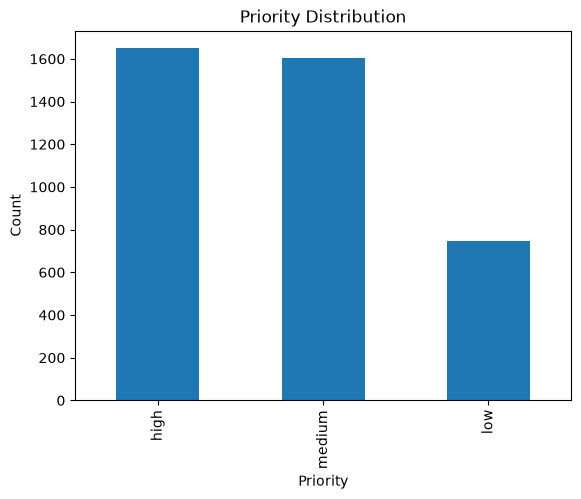

In [7]:
# Check Target Distribution
print(df["priority"].value_counts())

df["priority"].value_counts().plot(kind="bar")

plt.title("Priority Distribution")

plt.xlabel("Priority")

plt.ylabel("Count")

plt.show()

In [8]:
# Split Data
X = df["text"]

y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [10]:
# Logistic Regression Model & training
lr_model = Pipeline(
    [
        ("tfidf", tfidf),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['high','low','medium']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [11]:
# Random Forest Model & training
rf_model = Pipeline([
    ("tfidf", tfidf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['high','low','medium']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [12]:
# Prediction
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [13]:
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.58625
Random Forest Accuracy: 0.62125


In [14]:
# Classification Reports
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        high       0.63      0.75      0.68       330
         low       0.55      0.20      0.29       150
      medium       0.55      0.60      0.57       320

    accuracy                           0.59       800
   macro avg       0.57      0.52      0.52       800
weighted avg       0.58      0.59      0.57       800

Random Forest Classification Report:
              precision    recall  f1-score   support

        high       0.65      0.78      0.71       330
         low       0.76      0.21      0.33       150
      medium       0.57      0.65      0.61       320

    accuracy                           0.62       800
   macro avg       0.66      0.55      0.55       800
weighted avg       0.64      0.62      0.60       800



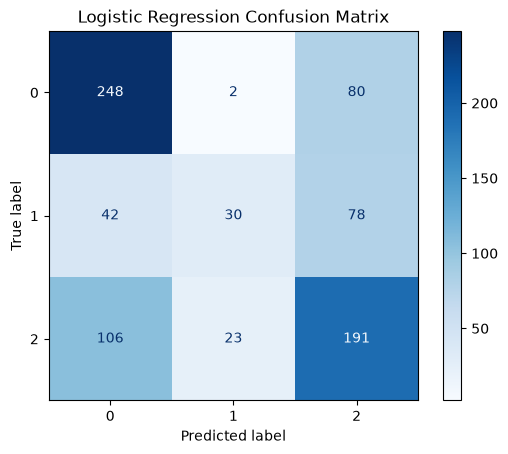

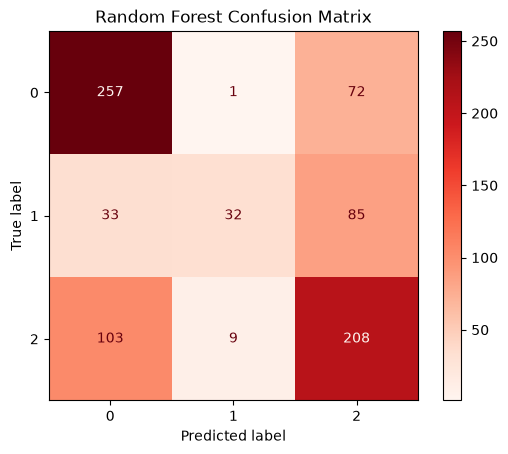

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Reds")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [16]:
# Predict New Ticket
ticket = """
AWS production server is down.
Users cannot access the application.
Need urgent support.
"""

print("Logistic Regression Prediction:")
print(lr_model.predict([ticket]))

print("Random Forest Prediction:")
print(rf_model.predict([ticket]))

Logistic Regression Prediction:
['high']
Random Forest Prediction:
['high']


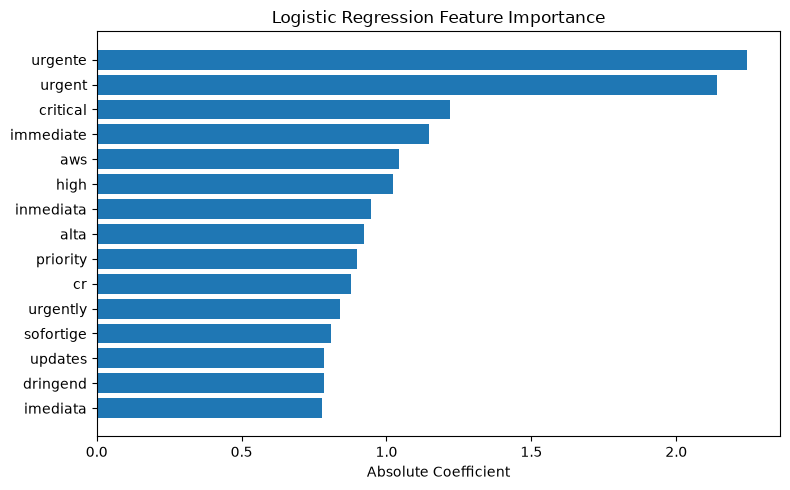

In [19]:
# Logistic Regression Feature Importance

feature_names = lr_model.named_steps["tfidf"].get_feature_names_out()
coef = np.mean(np.abs(lr_model.named_steps["classifier"].coef_), axis=0)

top = np.argsort(coef)[-15:]

plt.figure(figsize=(8,5))
plt.barh(feature_names[top], coef[top])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()

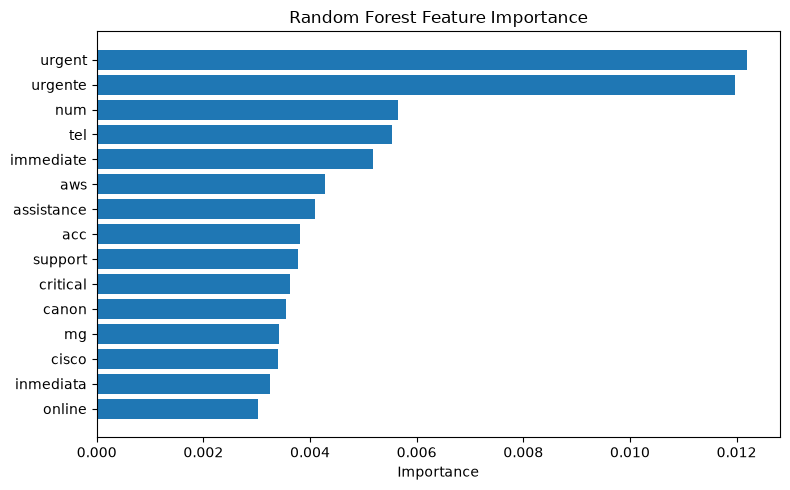

In [20]:
# Random Forest Feature Importance

feature_names = rf_model.named_steps["tfidf"].get_feature_names_out()
importance = rf_model.named_steps["classifier"].feature_importances_

top = np.argsort(importance)[-15:]

plt.figure(figsize=(8,5))
plt.barh(feature_names[top], importance[top])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()